## Baixando Bibliotecas

In [1]:
# Inclusão das bibliotecas usadas no trabalho
import numpy as np
import matplotlib.pyplot as plt
import csv

## Carregando os dados do Dataset

In [2]:
# Função para carregar dados do CSV
def carregar_dados(arquivo):
    X, y = [], []
    with open(arquivo, 'r') as f:
        leitor = csv.reader(f)
        next(leitor) # pular cabeçalho
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])]) # idade, salário
            y.append(int(linha[2]))
    return np.array(X), np.array(y)

# Carregando o dataset
X, y = carregar_dados("test_dataset1.csv")
print("Formato dos dados: ", X.shape, y.shape)
print("Primeiras amostras:\n", X[:5], "\nRótulos:", y[:5])

Formato dos dados:  (60, 2) (60,)
Primeiras amostras:
 [[ 0.16133991  0.55611507]
 [ 0.02054845  0.37250535]
 [-0.56956854  0.546234  ]
 [ 0.99591052 -0.12652222]
 [ 0.90825218  0.96756404]] 
Rótulos: [ 1  1  1 -1  1]


## Declaração da Classe

In [3]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000, weight_init="random"):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.weight_init = weight_init
        self.bias = None
        self.errors_per_epoch = [] # Armazena o erro a cada época
    
    # Inicializando os pesos de forma customizada
    def _initialize_weights(self, n_features):
        """ Inicializa os pesos de acordo com o método escolhido """
        if self.weight_init == "random":
            self.weights = np.random.rand(n_features)
            self.bias = np.random.rand()
        elif self.weight_init == "zeros":
            self.weights = np.zeros(n_features)
            self.bias = 0
        elif self.weight_init == "normal":
            self.weights = np.random.randn(n_features) * 0.01 # Pequenos valores gaussianos
            self.bias = np.random.randn() * 0.01
        else:
            raise ValueError("Opção inválida para inicialização dos pesos")
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        #self.weights = npzeros(n_features)
        self._initialize_weights(n_features) # Inicializando os pesos dinamicamente
        self.bias = 0
        
        for epoch in range(self.n_epochs):
            errors = 0 # Contador de erros por época

            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = np.sign(linear_output)

                # Atualização dos pesos se houver erro
                if y_pred != y[i]:
                    self.weights += self.learning_rate * y[i] * X[i]
                    self.bias += self.learning_rate * y[i]
                    errors += 1 # Incrementa erro se classificação errada

            # Armazena a taxa de erro (erros / total de amostras)
            self.errors_per_epoch.append(errors / n_samples)

            # Parada antecipada se não houver erros
            if errors == 0:
                break

            # Após o treinamento, calcular e exibir estatísticas
            self._print_training_summary(X, y, epoch + 1)

    # Método para exibir a acurácia e pesos finais
    def _print_training_summary(self, X, y, epochs):
        y_pred = self.predict(X)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print("\n===== Resumo do Treinamento =====")
        print(f"Acurácia no conjunto de treino: {accuracy:.2f}%")
        print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("===================================")

    # Retorna a predição com base no treinamento do Perceptron
    def predict(self, X):
        return np.sign(np.dot(X, self.weights) + self.bias)
    
    # Faz previsões e, se os rótulos forem fornecidos, exibe métricas
    # Coloque esse método (não está no slide)
    def predict2(self, X, y, y_true=None):
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)

        # Se y_true for fornecido, calcular métricas de avaliação
        if y_true is not None:
            self.predict_summary(X, y_true, 0, "Teste")

        return y_pred

    # Calculando as métricas de predição
    def predict_summary(self, X, y, epochs, phase):
        """ Método para exibir a acurácia, desvio padrão e pesos finais """
        y_pred = np.sign(np.dot(X, self.weights) + self.bias)
        accuracy = np.mean(y_pred == y) * 100
        std_dev = np.std(self.weights)

        print(f"\n===== Resumo do {phase} ======")
        print(f"Acurácia no conjunto de {phase.lower()}: {accuracy:.2f}%")
        print(f"Desvio Padrão dos Pesos: {std_dev:.5f}")
        if epochs > 0:
            print(f"Número total de épocas: {epochs}")
        print(f"Pesos finais aprendidos: {self.weights}")
        print(f"Bias final: {self.bias}")
        print("====================================")

    # Plota o gráfico da evolução dos erros ao longo das épocas de treinamento.
    def plot_error(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.errors_per_epoch, marker='o', linestyle='-')
        plt.xlabel('Época')
        plt.ylabel('Taxa de erro')
        plt.title('Evolução do erro ao longo das épocas')
        plt.grid()
        plt.show()

## Função para plotar a fronteira de decisão

In [4]:
# Gráfico da 'fronteira' gerado pelo Perceptron
def plot_decision_boundary(X, y, model, title="Fronteira de Decisão do Perceptron"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar o gráfico
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(title)
    plt.show()

## Declaração do metotodo plot_comparison

In [5]:
# Função para plotar lado a lado: dataset e fronteira de decisão
def plot_comparison(X, y, model):
    # Criar uma grade para o plano cartesiano
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predição para cada ponto da grade
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Criar os subplots (1 linha, 2 colunas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1 - Fronteira de Decisão
    axes[0].contourf(xx, yy, Z, alpha=0.3)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    axes[0].set_xlabel("X1")
    axes[0].set_ylabel("X2")
    axes[0].set_title("Fronteira de Decisão do Perceptron")

    # Subplot 2 - Apenas os Dados
    axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    axes[1].set_xlabel("X1")
    axes[1].set_ylabel("X2")
    axes[1].set_title("Distribuição dos Dados do Dataset")

    plt.tight_layout()
    plt.show()

## Treinando o Perceptron com dados do Dataset1


===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 98.57%
Número total de épocas: 1
Pesos finais aprendidos: [-0.36317347  0.30622854]
Bias final: 0.1

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 89.29%
Número total de épocas: 2
Pesos finais aprendidos: [-0.38044095  0.26410268]
Bias final: 0.2

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 96.43%
Número total de épocas: 3
Pesos finais aprendidos: [-0.43934749  0.5742005 ]
Bias final: 0.1

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 95.71%
Número total de épocas: 4
Pesos finais aprendidos: [-0.48748515  0.57761538]
Bias final: 0.2

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 96.43%
Número total de épocas: 5
Pesos finais aprendidos: [-0.59760853  0.43477244]
Bias final: 0.20000000000000004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 98.57%
Número total de épocas: 6
Pesos finais aprendidos: [-0.60170917  0.46978293

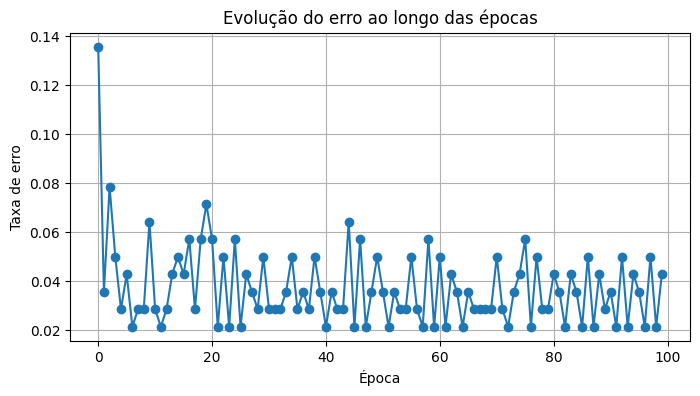

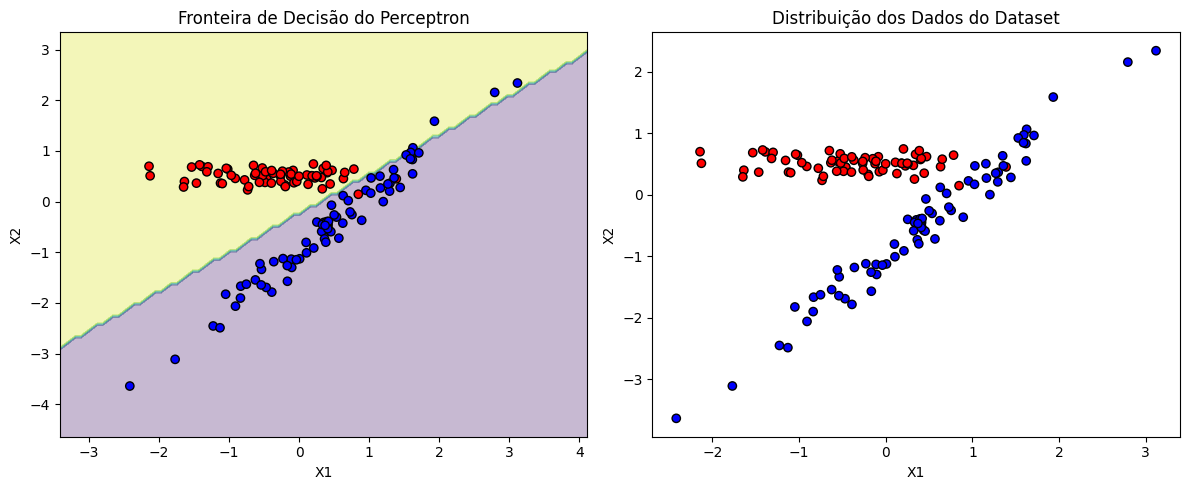

In [6]:
# Dataset 1 - Importando o dataset de treino
train_dataset1 = np.loadtxt("train_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)

## Testando o Perceptron com dados do Dataset1


===== Resumo do Teste ======
Acurácia no conjunto de teste: 91.67%
Desvio Padrão dos Pesos: 0.76375
Pesos finais aprendidos: [-0.66601952  0.8614839 ]
Bias final: 0.20000000000000004


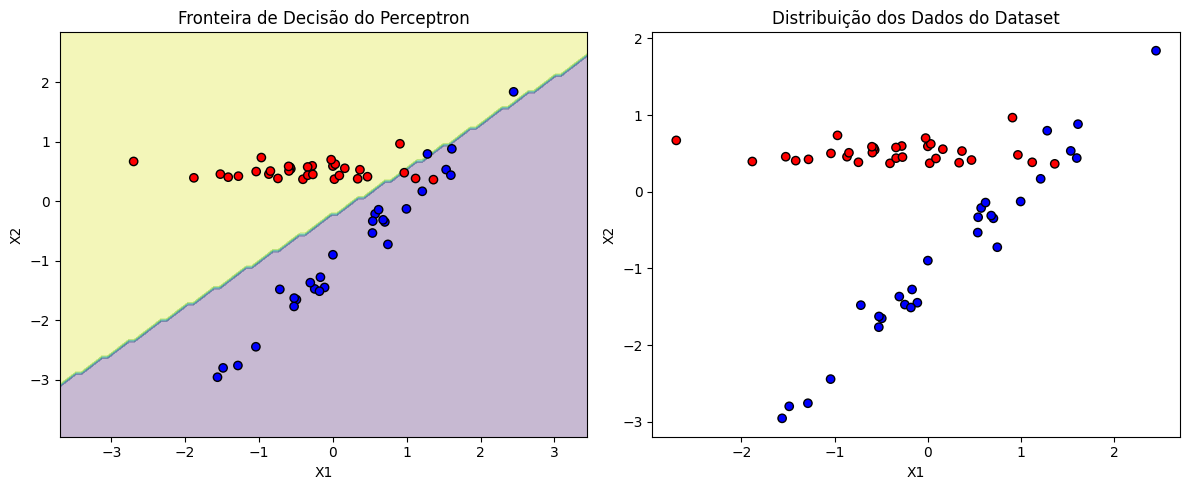

In [7]:
# Dataset 1 - Importando o dataset de treino
test_dataset1 = np.loadtxt("test_dataset1.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X_test = test_dataset1[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset1[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)

## Treinando o Perceptron com Dados do Dataset2


===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.00%
Número total de épocas: 1
Pesos finais aprendidos: [ 0.06935633 -0.1302425 ]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.00%
Número total de épocas: 2
Pesos finais aprendidos: [ 0.0939479  -0.02918304]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.57%
Número total de épocas: 3
Pesos finais aprendidos: [ 0.08376409 -0.05846344]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 49.14%
Número total de épocas: 4
Pesos finais aprendidos: [ 0.06121416 -0.12046059]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 49.71%
Número total de épocas: 5
Pesos finais aprendidos: [ 0.06654462 -0.06919053]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino

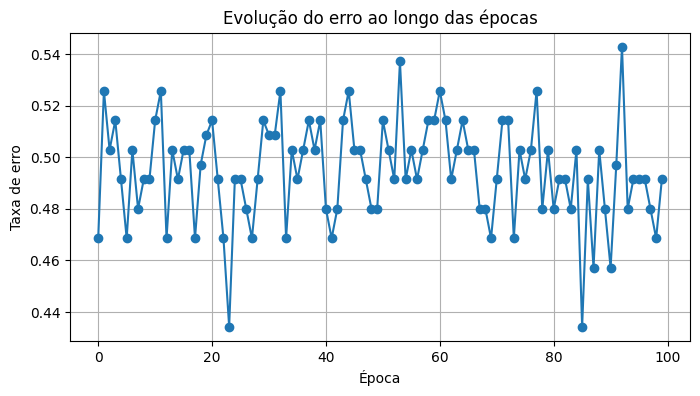

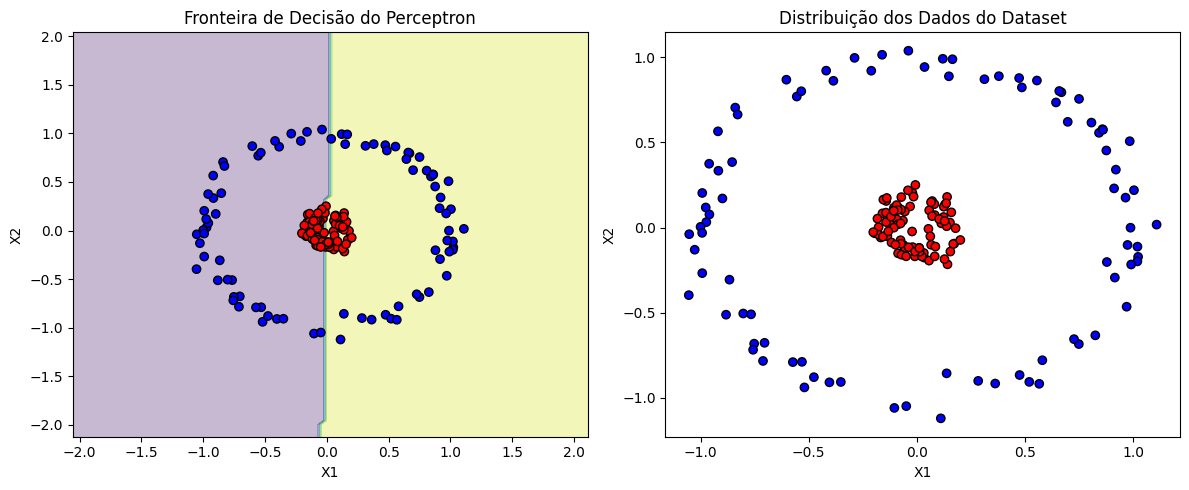

In [8]:
# Dataset 2 - Importando o dataset de treino
train_dataset2 = np.loadtxt("train_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y = train_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron e definição da taxa de aprendizado como 0.1 e número de épocas em 100
perceptron = Perceptron(learning_rate=0.1, n_epochs=100)

# Treinamento do Perceptron
perceptron.fit(X, y)

# Fazer previsões
y_pred = perceptron.predict2(X, y)

# Plotar a evolução do erro
perceptron.plot_error()

print("")

# Plot dos gráficos lado a lado
plot_comparison(X, y, perceptron)

## Testando o Perceptron com Dados do Dataset2


===== Resumo do Teste ======
Acurácia no conjunto de teste: 58.67%
Desvio Padrão dos Pesos: 0.05260
Pesos finais aprendidos: [ 0.10329193 -0.00190108]
Bias final: -2.7755575615628914e-17


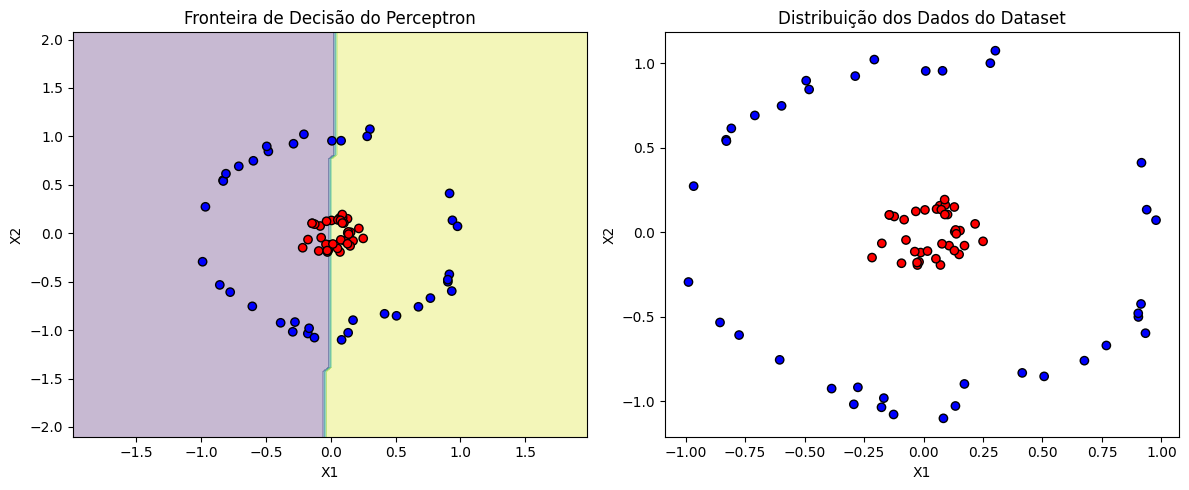

In [9]:
# Dataset 2 - Importando o dataset de treino
test_dataset2 = np.loadtxt("test_dataset2.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X_test = test_dataset2[:, :2] # As duas primeiras colunas são os atributos (X1 e X2)
y_test = test_dataset2[:, 2] # Terceira coluna (rótulos)

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y_test = np.where(y_test == -1, -1, 1)

# Fazer previsões
perceptron.predict2(X_test, y, y_test)

# Plot dos gráficos lado a lado
plot_comparison(X_test, y_test, perceptron)


## Treinando o Perceptron com Dados do Dataset3

Cenário 1 - Tx Treinamento: 0.1 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 91.84%
Número total de épocas: 1
Pesos finais aprendidos: [-0.16620115 -0.25255091  0.18992659 -0.033656    0.13980461  0.06070272
  0.12469673  0.3610615  -0.05328388  1.1469643 ]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 91.16%
Número total de épocas: 2
Pesos finais aprendidos: [ 0.11782297 -0.08150247 -0.13169716 -0.18765553  0.15572871  0.07531078
 -0.01835528  0.18404201 -0.0877547   1.12616951]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 89.80%
Número total de épocas: 3
Pesos finais aprendidos: [ 0.08131301 -0.15513085 -0.06024186 -0.28194506  0.3064415   0.09995856
  0.13159502  0.09357416 -0.14559051  1.0356832 ]
Bias final: -0.10000000000000003

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 91.16%
Número total de épocas: 4
Pesos 

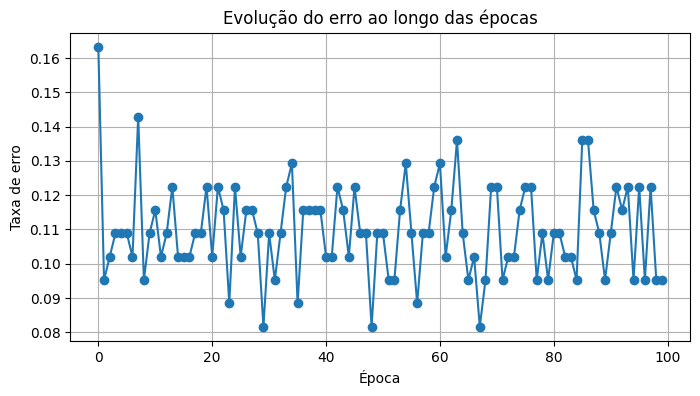


Cenário 2 - Tx Treinamento: 0.1 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 91.84%
Número total de épocas: 1
Pesos finais aprendidos: [-0.21923842 -0.23207983 -0.23751802  0.03283919  0.1048476   0.04068474
  0.06465548  0.09529112 -0.13657407  0.89720801]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 86.39%
Número total de épocas: 2
Pesos finais aprendidos: [-0.0975206  -0.38509572 -0.11470037 -0.15759878  0.22043622 -0.25517796
 -0.04461873  0.3232239  -0.03160772  0.92485879]
Bias final: -2.7755575615628914e-17

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 88.44%
Número total de épocas: 3
Pesos finais aprendidos: [ 0.08205955 -0.35590045 -0.28094592 -0.19530578  0.32145788 -0.01159714
  0.14716498  0.21004757  0.01667971  1.03990151]
Bias final: 0.09999999999999998

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 90.48%
Número total de épocas: 4
Pesos 

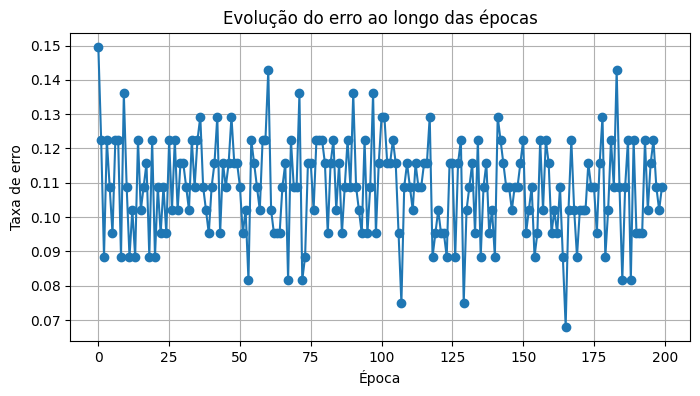


Cenário 3 - Tx Treinamento: 0.001 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 80.27%
Número total de épocas: 1
Pesos finais aprendidos: [0.66712518 0.11113515 0.09561873 0.7086021  0.09399342 0.30412862
 0.82203607 0.29798098 0.22741672 0.96769557]
Bias final: -0.003

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 80.95%
Número total de épocas: 2
Pesos finais aprendidos: [0.65025204 0.10443787 0.09384657 0.69185915 0.09299164 0.29608753
 0.80642689 0.29363975 0.20114881 0.98243406]
Bias final: -0.008

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 80.27%
Número total de épocas: 3
Pesos finais aprendidos: [0.63316916 0.09927651 0.09409546 0.67634874 0.09307663 0.28946444
 0.79072784 0.29237419 0.17639394 0.99436795]
Bias final: -0.011000000000000003

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 80.95%
Número total de épocas: 4
Pesos finais aprendidos: [0.61608627 0.09411515 0.09434435 0.66083

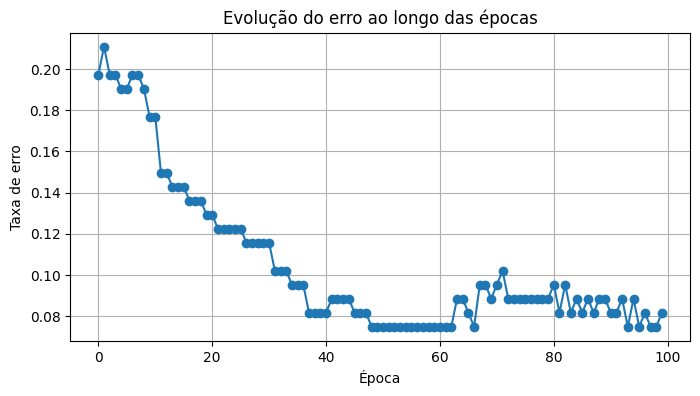


Cenário 4 - Tx Treinamento: 0.001 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 68.03%
Número total de épocas: 1
Pesos finais aprendidos: [0.57818674 0.05290549 0.24543879 0.93866391 0.85904569 0.10633835
 0.4801963  0.62518532 0.27516688 0.90641735]
Bias final: -0.002

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 72.11%
Número total de épocas: 2
Pesos finais aprendidos: [0.56039079 0.04665584 0.23935455 0.91086041 0.83093607 0.10517994
 0.47940303 0.61790111 0.24776061 0.93809746]
Bias final: -0.005

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 72.11%
Número total de épocas: 3
Pesos finais aprendidos: [0.5422082  0.04258185 0.23330247 0.88486559 0.80527156 0.10299859
 0.47963739 0.61128666 0.22068559 0.96490806]
Bias final: -0.010000000000000002

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 74.83%
Número total de épocas: 4
Pesos finais aprendidos: [0.5259784  0.03937688 0.22820888 0.85951

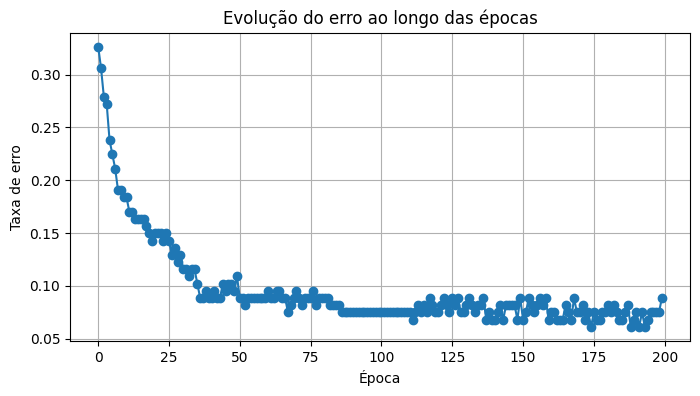


Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 50.34%
Número total de épocas: 1
Pesos finais aprendidos: [0.01867575 0.1877007  0.588314   0.46523985 0.07105918 0.10331719
 0.38044633 0.17279707 0.67288402 0.11366889]
Bias final: -0.0009000000000000002

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 53.06%
Número total de épocas: 2
Pesos finais aprendidos: [0.01881046 0.18499153 0.58621231 0.46258831 0.06999667 0.10339847
 0.37891983 0.17292646 0.6660532  0.12094658]
Bias final: -0.0018000000000000006

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 53.06%
Número total de épocas: 3
Pesos finais aprendidos: [0.0187766  0.18242422 0.58414228 0.45994164 0.06886059 0.10326431
 0.3775137  0.17286467 0.65923627 0.12790829]
Bias final: -0.0024999999999999996

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 53.06%
Número total de épocas: 4
Pesos finais aprendidos: [0.0187

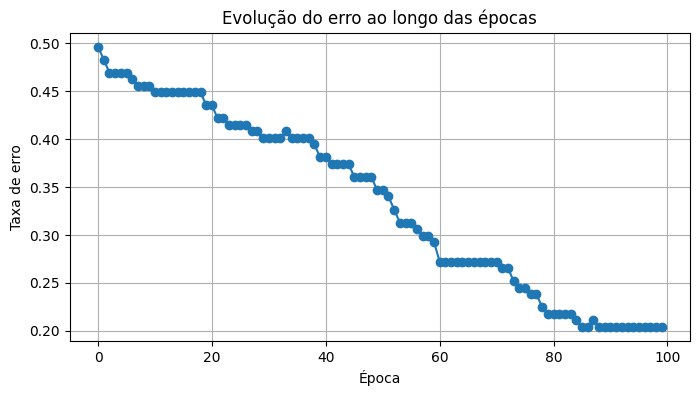


Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 1
Pesos finais aprendidos: [0.25113275 0.48038121 0.84849055 0.36591957 0.89233625 0.04996019
 0.65139942 0.7294156  0.70033067 0.15916824]
Bias final: -0.0004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 46.94%
Número total de épocas: 2
Pesos finais aprendidos: [0.25056179 0.47808    0.84554211 0.36453286 0.8892916  0.05055806
 0.65002885 0.72819948 0.69513018 0.16718613]
Bias final: -0.0008000000000000001

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 47.62%
Número total de épocas: 3
Pesos finais aprendidos: [0.24999312 0.47583441 0.84254106 0.36329021 0.88622274 0.05123168
 0.64857519 0.72702414 0.69001467 0.17490156]
Bias final: -0.0013000000000000004

===== Resumo do Treinamento =====
Acurácia no conjunto de treino: 48.30%
Número total de épocas: 4
Pesos finais aprendidos: [0.2493089  0.47351916

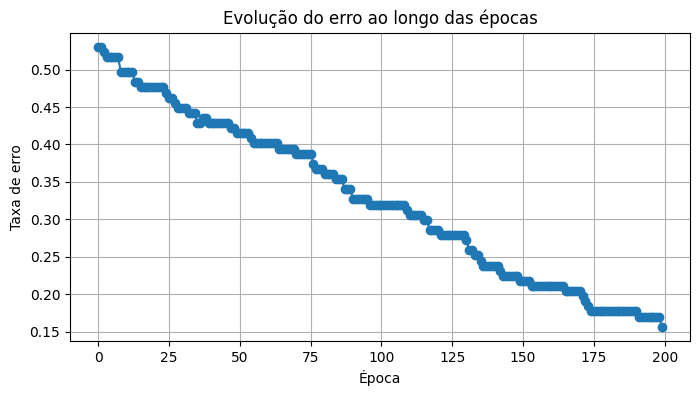

In [10]:
# Dataset 3 - Importando o dataset de treino
train_dataset3 = np.loadtxt("train_dataset3.csv", delimiter=",", skiprows=1, dtype=float)

# Definições das entradas
X = train_dataset3[:, :-1] # Todas as colunas, exceto a última (10 features)
y = train_dataset3[:, -1] # ÚLtima coluna é o rótulos

# Converter rótulos para -1 e 1 (caso estejam diferentes)
y = np.where(y == -1, -1, 1)

# Criação do Perceptron de acordo com os cenários da tabela
perceptron_cenario_1 = Perceptron(learning_rate=0.1, n_epochs=100)
perceptron_cenario_2 = Perceptron(learning_rate=0.1, n_epochs=200)
perceptron_cenario_3 = Perceptron(learning_rate=0.001, n_epochs=100)
perceptron_cenario_4 = Perceptron(learning_rate=0.001, n_epochs=200)
perceptron_cenario_5 = Perceptron(learning_rate=0.0001, n_epochs=100)
perceptron_cenario_6 = Perceptron(learning_rate=0.0001, n_epochs=200)

# --------------------------------------------------------------------
# Cenário 1
print("Cenário 1 - Tx Treinamento: 0.1 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_1.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_1.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 2
print("Cenário 2 - Tx Treinamento: 0.1 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_2.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_2.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 3
print("Cenário 3 - Tx Treinamento: 0.001 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_3.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_3.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 4
print("Cenário 4 - Tx Treinamento: 0.001 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_4.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_4.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 5
print("Cenário 5 - Tx Treinamento: 0.0001 | Épocas 100")

#Treinamento do Perceptron 
perceptron_cenario_5.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_5.plot_error()
print("")

# --------------------------------------------------------------------
# Cenário 6
print("Cenário 6 - Tx Treinamento: 0.0001 | Épocas 200")

#Treinamento do Perceptron 
perceptron_cenario_6.fit(X, y)

#PLotar a evolução do erro
perceptron_cenario_6.plot_error()
print("")

## Testando o Perceptron com Dados do Dataset3